In [20]:
import torch
import numpy as np
import pandas as pd
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

In [21]:
seed = 10
torch.manual_seed(seed)
np.random.seed(seed)

In [22]:
# Terminal Colors
RED = "\033[31;1m"
GREEN = "\033[32;1m"
YELLOW = "\033[33;1m"
BLUE = "\033[34;1m"
PURPLE = "\033[35;1m"
CYAN = "\033[36;1m"
TEAL = "\033[38;5;37m"
WHITE = "\033[37;1m"
ORANGE = "\033[38;5;208m"
RESET = "\033[0;0m"

In [23]:
#Variables
EPOCHS = 100
BATCH_SIZE = 16
LEARNING_RATE = 0.001
HIDDEN = [64, 32, 16]
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"{PURPLE}Using Device: {DEVICE}")

Using Device: cpu


In [24]:
file_path = "/content/drive/MyDrive/Colab Notebooks/optimizers/cancer.csv"

In [25]:
dataframe = pd.read_csv(file_path, index_col=0)

In [26]:
dataframe.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [27]:
#Loading the dataset
x = dataframe.drop(columns=['target']).values
y = dataframe['target'].values

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.225, random_state=seed, stratify=y)
stdz = StandardScaler()
x_train = stdz.fit_transform(x_train)
x_test = stdz.transform(x_test)

x_train_t = torch.tensor(x_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
x_test_t = torch.tensor(x_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

train_loader = DataLoader(TensorDataset(x_train_t, y_train_t), batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(TensorDataset(x_test_t, y_test_t), batch_size=BATCH_SIZE)

In [28]:
#Building Model
class FNN(nn.Module):
  def __init__(self, input_dim, hidden_dim) -> None:
    super().__init__()
    layers, prev = [], input_dim
    for h in hidden_dim:
      layers += [nn.Linear(prev, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(0.3)]
      prev = h

    layers.append(nn.Linear(prev, 1))
    self.net = nn.Sequential(*layers)

  def forward(self, x):
    return self.net(x)

In [29]:
def build_model():
  return FNN(input_dim=x_train_t.shape[1], hidden_dim=HIDDEN).to(DEVICE)

In [30]:
#Optimizer Config
OPTIMIZER_CONFIGS = {
    "SGD + Momentum": lambda p: optim.SGD(p, lr=LEARNING_RATE, momentum=0.9, weight_decay=1e-4),
    "AdaGrad": lambda p: optim.Adagrad(p, lr=LEARNING_RATE, weight_decay=1e-4),
    "RMSProp": lambda p: optim.RMSprop(p, lr=LEARNING_RATE, alpha=0.99, weight_decay=1e-4),
    "Adam": lambda p: optim.Adam(p, lr=LEARNING_RATE, betas=(0.9, 0.999), weight_decay=1e-4)
}

COLORS = {
    "SGD + Momentum": "#E63946",
    "AdaGrad": "#F4A261",
    "RMSProp": "#2A9D8F",
    "Adam": "#457B9D"

}

In [31]:
#Training Functions
criterion = nn.BCEWithLogitsLoss()

In [32]:
from torch.types import Device
def train_epoch(model, loader, optimizer):
  model.train()
  total_loss, correct, total = 0.0, 0, 0

  for xb, yb in loader:
    xb, yb = xb.to(DEVICE), yb.to(DEVICE)
    optimizer.zero_grad()
    logits = model(xb)
    loss = criterion(logits, yb)
    loss.backward()
    optimizer.step()
    total_loss += loss.item() * xb.size(0)
    total += xb.size(0)
    correct += ((torch.sigmoid(logits) >= 0.5).float() == yb).sum().item()

  return total_loss / total, correct / total

In [33]:
@torch.no_grad()
def evaluate(model, loader):
  model.eval()
  total_loss, correct, total = 0.0, 0, 0
  preds_all, targets_all = [], []

  for xb, yb in loader:
    xb, yb = xb.to(DEVICE), yb.to(DEVICE)
    logits = model(xb)
    total_loss += criterion(logits, yb).item() * xb.size(0)
    pred = (torch.sigmoid(logits) >= 0.5).float()
    correct += (pred == yb).sum().item()
    total += xb.size(0)
    preds_all.extend(pred.cpu().numpy())
    targets_all.extend(yb.cpu().numpy())

  return total_loss / total, correct / total, np.array(preds_all), np.array(targets_all)

In [34]:
#Running Everything
history, final_metrics = {}, {}

In [35]:
for name, opt_fn in OPTIMIZER_CONFIGS.items():
  print(f"{ORANGE}" + "=" * 70)
  print(f"{YELLOW}{name}")
  print(f"{ORANGE}" + "=" * 70)

  model = build_model()
  optimizer = opt_fn(model.parameters())
  scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

  h = {
      "train_loss": [],
      "val_loss": [],
      "train_acc": [],
      "val_acc": []
  }

  for epoch in range(1, EPOCHS+1):
    tr_l, tr_a = train_epoch(model, train_loader, optimizer)
    vl_l, vl_a, preds, targets = evaluate(model, test_loader)

    scheduler.step()

    h["train_loss"].append(tr_l)
    h["val_loss"].append(vl_l)
    h["train_acc"].append(tr_a)
    h["val_acc"].append(vl_a)

    if epoch % 25 == 0 or epoch == 1:
      print(f"{TEAL}Epoch: {epoch:3d} | TrLoss: {tr_l:.4f} TrAcc: {tr_a:.4f} |",
            f"{CYAN}VlLoss: {vl_l:.4f} VlAcc: {vl_a:.2%}"
            )

    history[name] = h
    final_metrics[name] = {"acc":vl_a*100, "loss":vl_l, "preds":preds, "targets":targets}

SGD + Momentum
Epoch:   1 | TrLoss: 0.7068 TrAcc: 0.4909 | VlLoss: 0.6808 VlAcc: 45.74%
Epoch:  25 | TrLoss: 0.2261 TrAcc: 0.9455 | VlLoss: 0.1816 VlAcc: 96.90%
Epoch:  50 | TrLoss: 0.1807 TrAcc: 0.9364 | VlLoss: 0.1161 VlAcc: 99.22%
Epoch:  75 | TrLoss: 0.1596 TrAcc: 0.9500 | VlLoss: 0.0979 VlAcc: 99.22%
Epoch: 100 | TrLoss: 0.1734 TrAcc: 0.9386 | VlLoss: 0.0938 VlAcc: 98.45%
AdaGrad
Epoch:   1 | TrLoss: 0.7488 TrAcc: 0.4636 | VlLoss: 0.6620 VlAcc: 41.86%
Epoch:  25 | TrLoss: 0.5045 TrAcc: 0.7886 | VlLoss: 0.4751 VlAcc: 91.47%
Epoch:  50 | TrLoss: 0.4616 TrAcc: 0.8682 | VlLoss: 0.4258 VlAcc: 91.47%
Epoch:  75 | TrLoss: 0.4475 TrAcc: 0.8591 | VlLoss: 0.4210 VlAcc: 93.80%
Epoch: 100 | TrLoss: 0.4416 TrAcc: 0.8750 | VlLoss: 0.4214 VlAcc: 93.80%
RMSProp
Epoch:   1 | TrLoss: 0.4597 TrAcc: 0.8364 | VlLoss: 0.3436 VlAcc: 94.57%
Epoch:  25 | TrLoss: 0.1350 TrAcc: 0.9455 | VlLoss: 0.0741 VlAcc: 98.45%
Epoch:  50 | TrLoss: 0.0902 TrAcc: 0.9705 | VlLoss: 0.0684 VlAcc: 98.45%
Epoch:  75 | TrLoss:

In [36]:
print(f"{GREEN}Final Test Accuracy: {vl_a:.2%}")
print(f"{WHITE}Classification Report:\n{classification_report(targets, preds, target_names=["No Cancer", "Cancer"])}")

Final Test Accuracy: 98.45%
Classification Report:
              precision    recall  f1-score   support

   No Cancer       1.00      0.96      0.98        48
      Cancer       0.98      1.00      0.99        81

    accuracy                           0.98       129
   macro avg       0.99      0.98      0.98       129
weighted avg       0.98      0.98      0.98       129



In [37]:
#Visualization
BG = "#0F1117"

Plot saved


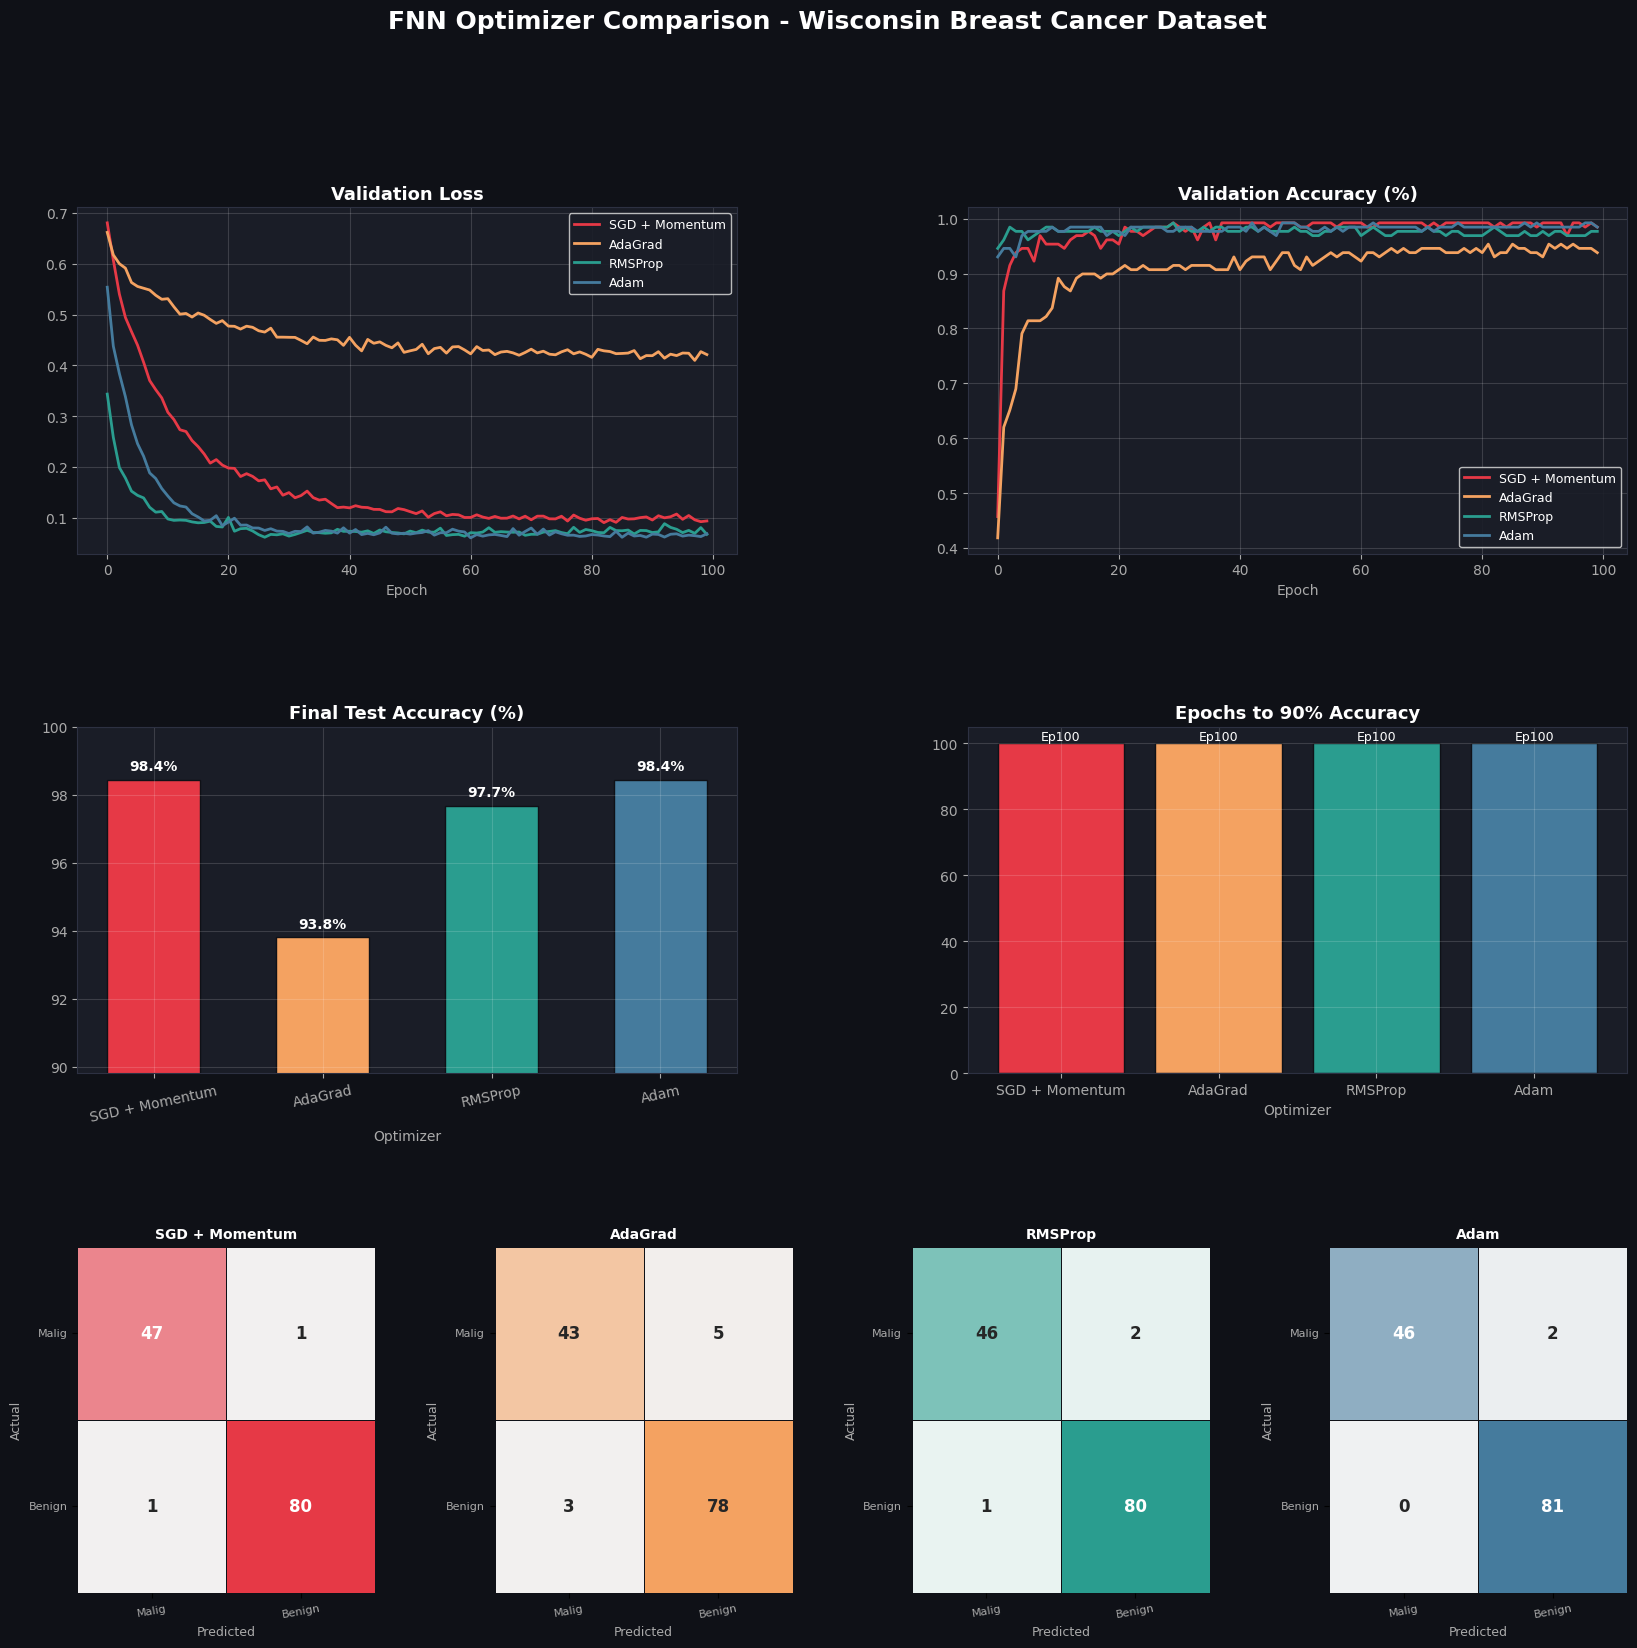

In [40]:
fig = plt.figure(figsize=(20, 18), facecolor=BG)
fig.suptitle("FNN Optimizer Comparison - Wisconsin Breast Cancer Dataset", fontsize=18, fontweight="bold", color="white", y=0.99)

gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.5, wspace=0.35)
gs_cm = gridspec.GridSpecFromSubplotSpec(1, 4, subplot_spec=gs[2, :], wspace=0.4)

ax_loss = fig.add_subplot(gs[0, 0])
ax_acc = fig.add_subplot(gs[0, 1])
ax_bar = fig.add_subplot(gs[1, 0])
ax_conv = fig.add_subplot(gs[1, 1])
axes_cm = [fig.add_subplot(gs_cm[i]) for i in range(0, 4)]

def dark_ax(ax, title):
  ax.set_facecolor("#1A1D27")
  ax.spines[:].set_color("#2D3142")
  ax.tick_params(colors="#AAAAAA")
  ax.set_title(title, color="white", fontsize=13, fontweight="bold")
  ax.grid(alpha=0.15, color="white")

names = list(history.keys())

for name, h in history.items():
  c = COLORS[name]
  ax_loss.plot(h["val_loss"], label=name, color=c, lw=2)
  ax_acc.plot(h["val_acc"], label=name, color=c, lw=2)

for ax, title, xlabel in [
    (ax_loss, "Validation Loss", "Epoch"),
    (ax_acc, "Validation Accuracy (%)", "Epoch")
]:

    dark_ax(ax, title)
    ax.set_xlabel(xlabel, color="#AAA")
    ax.legend(facecolor="#1A1D27", framealpha=0.9, labelcolor="white", fontsize=9)

accs = [final_metrics[n]["acc"] for n in names]
bars = ax_bar.bar(names, accs, color=[COLORS[n] for n in names], width=0.55, edgecolor="#0F1117")
dark_ax(ax_bar, "Final Test Accuracy (%)")
ax_bar.set_ylim(min(accs) - 4, 100)
ax_bar.tick_params(axis="x", rotation=12)
ax_bar.set_xlabel("Optimizer", color="#AAA")
for bar, acc in zip(bars, accs):
  ax_bar.text(
      bar.get_x() + bar.get_width() / 2,
      bar.get_height() + 0.2,
      f"{acc:.1f}%",
      ha="center",
      va="bottom",
      color="white",
      fontsize=10,
      fontweight="bold"
  )

conv_ep = [next((i+1 for i, a in enumerate(history[n]["val_acc"]) if a >= 90), EPOCHS) for n in names]
hbars = ax_conv.bar(names, conv_ep, color=[COLORS[n] for n in names], edgecolor="#0F1117")
dark_ax(ax_conv, "Epochs to 90% Accuracy") # Changed title to something more descriptive
ax_conv.set_xlabel("Optimizer", color="#AAA") # Changed xlabel to Optimizer
for bar, ep in zip(hbars, conv_ep):
  ax_conv.text(
      bar.get_x() + bar.get_width() / 2, # Centered text above the bar
      bar.get_height() + 0.2, # Slightly above the bar
      f"Ep{ep}",
      ha="center",
      va="bottom",
      color="white",
      fontsize=9
  )

for ax, name in zip(axes_cm, names):
  m = final_metrics[name]
  cm = confusion_matrix(m["targets"], m["preds"])
  sns.heatmap(cm, annot=True, fmt="d", ax=ax, cmap=sns.light_palette(COLORS[name], as_cmap=True), linewidth=0.5, linecolor=BG, cbar=False, annot_kws={"size":12, "weight":"bold"}) # Changed char=False to cbar=False

  ax.set_title(name, color="white", fontsize=10, fontweight="bold")
  ax.set_xlabel("Predicted", color="#AAA", fontsize=9)
  ax.set_ylabel("Actual", color="#AAA", fontsize=9) # Fixed typo fonstize to fontsize
  ax.set_xticklabels(["Malig", "Benign"], color="#aaaaaa", rotation=10, fontsize=8)
  ax.set_yticklabels(["Malig", "Benign"], color="#aaaaaa", rotation=0, fontsize=8)
  ax.set_facecolor("#1A1D27")

dir = "/content/drive/MyDrive/Colab Notebooks/optimizers"
output = "optimzer_comparison.png"
plt.savefig(dir + output, dpi=150, bbox_inches="tight", facecolor=BG)
print("Plot saved")
plt.show()